## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [3]:
# Install if necessary
# ! pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# Load the Forest Fires dataset (UCI ID = 162)
forest_fires = fetch_ucirepo(id=162)

# X = predictors (features), y = target (area burned)
X = forest_fires.data.features
y = forest_fires.data.targets

# Check column names, data types, missing values
print(X.info())

# Summary statistics for all numeric columns
print(X.describe())

# First 5 rows of the target variable
print(y.head())

<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), str(2)
memory usage: 48.6 KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192    4.559477   


In [2]:
! pip install ucimlrepo


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), str(2)
memory usage: 48.6 KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192    4.559477   


### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

Shape: (517, 12)

Data Types:
 X          int64
Y          int64
month        str
day          str
FFMC     float64
DMC      float64
DC       float64
ISI      float64
temp     float64
RH         int64
wind     float64
rain     float64
dtype: object

Missing Values:
 X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
dtype: int64

Target Summary:
               area
count   517.000000
mean     12.847292
std      63.655818
min       0.000000
25%       0.000000
50%       0.520000
75%       6.570000
max    1090.840000

Skewness of area: 12.85
Skewness of log(area+1): 1.22


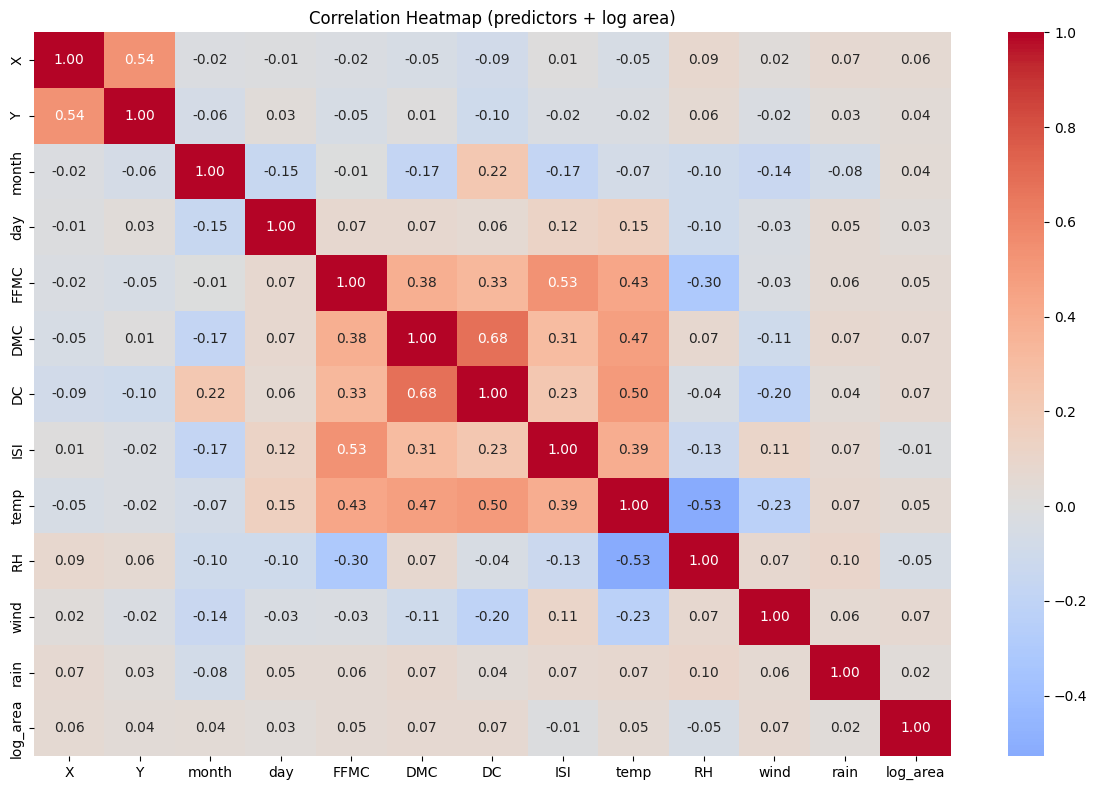


Correlation with log(area+1):
log_area    1.000000
DMC         0.067153
wind        0.066973
DC          0.066360
X           0.061995
temp        0.053487
FFMC        0.046799
month       0.039974
Y           0.038838
day         0.028812
rain        0.023311
ISI        -0.010347
RH         -0.053662
Name: log_area, dtype: float64


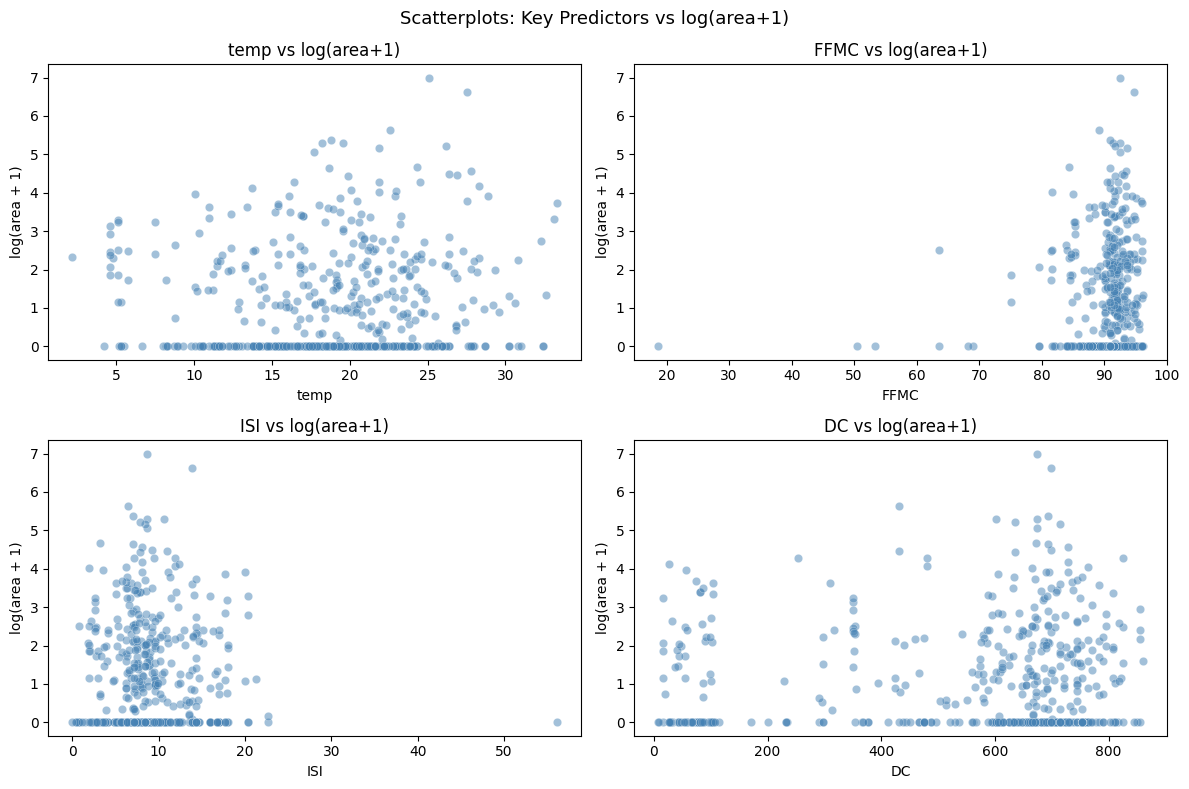

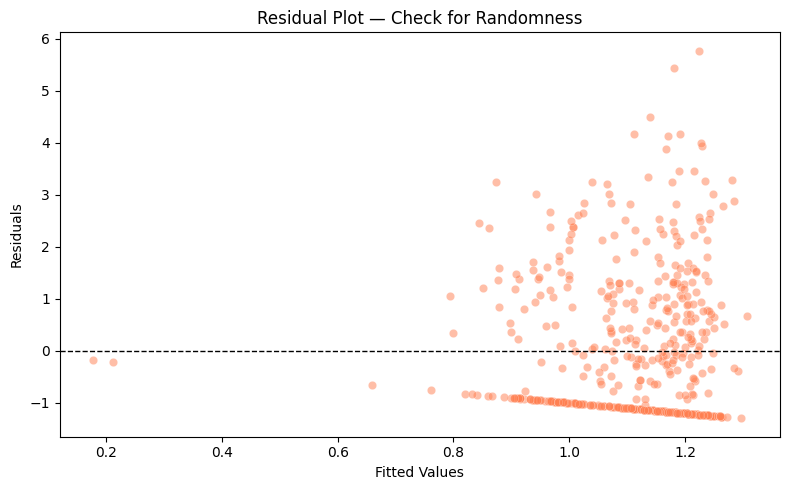


If residuals show a pattern (funnel/curve), the model needs transformations.
If scattered randomly around 0 — assumptions are met.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

# ── 1. Structure & Summary ───────────────────────────────────────────────────

print("Shape:", X.shape)
print("\nData Types:\n", X.dtypes)
print("\nMissing Values:\n", X.isnull().sum())
print("\nTarget Summary:\n", y.describe())

# Log-transform the target (area is heavily right-skewed)
y_log = np.log1p(y['area'])   # log(area + 1) avoids log(0)

print("\nSkewness of area:", round(y['area'].skew(), 2))
print("Skewness of log(area+1):", round(y_log.skew(), 2))

# ── 2. Correlation Analysis ──────────────────────────────────────────────────

# Encode categorical columns (month, day) so they can go into the heatmap
X_encoded = X.copy()
le = LabelEncoder()
for col in ['month', 'day']:
    X_encoded[col] = le.fit_transform(X_encoded[col])

# Combine predictors + log target into one df for correlation
df_corr = X_encoded.copy()
df_corr['log_area'] = y_log

corr_matrix = df_corr.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (predictors + log area)")
plt.tight_layout()
plt.show()

# Print top correlations with log_area specifically
print("\nCorrelation with log(area+1):")
print(corr_matrix['log_area'].sort_values(ascending=False))

# ── 3. Scatterplots — top numeric predictors vs log(area+1) ─────────────────

# Pick the 4 predictors most correlated with log_area
top_predictors = ['temp', 'FFMC', 'ISI', 'DC']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(top_predictors):
    axes[i].scatter(X[col], y_log, alpha=0.5, color='steelblue', edgecolors='white', linewidths=0.3)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("log(area + 1)")
    axes[i].set_title(f"{col} vs log(area+1)")

plt.suptitle("Scatterplots: Key Predictors vs log(area+1)", fontsize=13)
plt.tight_layout()
plt.show()

# ── 4. Residual Plot ─────────────────────────────────────────────────────────

# Fit a quick simple linear regression using the top 4 predictors
X_simple = X_encoded[top_predictors]

model = LinearRegression()
model.fit(X_simple, y_log)

y_pred = model.predict(X_simple)
residuals = y_log - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color='coral', edgecolors='white', linewidths=0.3)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot — Check for Randomness")
plt.tight_layout()
plt.show()

print("\nIf residuals show a pattern (funnel/curve), the model needs transformations.")
print("If scattered randomly around 0 — assumptions are met.")

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder

# ── Setup ────────────────────────────────────────────────────────────────────

X_encoded = X.copy()
le = LabelEncoder()
for col in ['month', 'day']:
    X_encoded[col] = le.fit_transform(X_encoded[col])

y_log = np.log1p(y['area'])

baseline_cols = ['temp', 'FFMC', 'ISI', 'DC', 'DMC', 'RH', 'wind', 'rain']

# ── MODEL 1: Baseline ────────────────────────────────────────────────────────

X1 = sm.add_constant(X_encoded[baseline_cols].copy())
model1 = sm.OLS(y_log, X1).fit()
print("Model 1 done — R²:", round(model1.rsquared, 4))

# ── MODEL 2: + Quadratic Terms ───────────────────────────────────────────────

X2 = X_encoded[baseline_cols].copy()
X2['temp_sq'] = X2['temp'] ** 2
X2['FFMC_sq'] = X2['FFMC'] ** 2
X2['ISI_sq']  = X2['ISI']  ** 2
X2 = sm.add_constant(X2)
model2 = sm.OLS(y_log, X2).fit()
print("Model 2 done — R²:", round(model2.rsquared, 4))

# ── MODEL 3: + Interaction Terms ─────────────────────────────────────────────

X3 = X_encoded[baseline_cols].copy()
X3['temp_sq']     = X3['temp'] ** 2
X3['FFMC_sq']     = X3['FFMC'] ** 2
X3['ISI_sq']      = X3['ISI']  ** 2
X3['temp_x_FFMC'] = X3['temp'] * X3['FFMC']
X3['temp_x_ISI']  = X3['temp'] * X3['ISI']
X3['wind_x_ISI']  = X3['wind'] * X3['ISI']
X3 = sm.add_constant(X3)
model3 = sm.OLS(y_log, X3).fit()
print("Model 3 done — R²:", round(model3.rsquared, 4))

# ── MODEL 4: + Dummy Variables ───────────────────────────────────────────────

month_dummies = pd.get_dummies(X['month'], prefix='month', drop_first=True).astype(int)
day_dummies   = pd.get_dummies(X['day'],   prefix='day',   drop_first=True).astype(int)

X4 = X_encoded[baseline_cols].copy()
X4['temp_sq']     = X4['temp'] ** 2
X4['FFMC_sq']     = X4['FFMC'] ** 2
X4['ISI_sq']      = X4['ISI']  ** 2
X4['temp_x_FFMC'] = X4['temp'] * X4['FFMC']
X4['temp_x_ISI']  = X4['temp'] * X4['ISI']
X4['wind_x_ISI']  = X4['wind'] * X4['ISI']
X4 = pd.concat([X4, month_dummies, day_dummies], axis=1)
X4 = sm.add_constant(X4)
model4 = sm.OLS(y_log, X4).fit()
print("Model 4 done — R²:", round(model4.rsquared, 4))

# ── MODEL 5: + Log Transformations ───────────────────────────────────────────

X5 = X_encoded[baseline_cols].copy()
X5['log_ISI']     = np.log1p(X5['ISI'])
X5['log_rain']    = np.log1p(X5['rain'])
X5['log_DMC']     = np.log1p(X5['DMC'])
X5 = X5.drop(columns=['ISI', 'rain', 'DMC'])
X5['temp_sq']     = X_encoded['temp'] ** 2
X5['temp_x_FFMC'] = X_encoded['temp'] * X_encoded['FFMC']
X5 = pd.concat([X5, month_dummies, day_dummies], axis=1)
X5 = sm.add_constant(X5)
model5 = sm.OLS(y_log, X5).fit()
print("Model 5 done — R²:", round(model5.rsquared, 4))

# ── Comparison Table ─────────────────────────────────────────────────────────

models = {
    'Model 1 — Baseline':         model1,
    'Model 2 — + Quadratic':      model2,
    'Model 3 — + Interactions':   model3,
    'Model 4 — + Dummies':        model4,
    'Model 5 — + Log Transforms': model5,
}

comparison = pd.DataFrame({
    'R²':     {name: round(m.rsquared, 4)     for name, m in models.items()},
    'Adj R²': {name: round(m.rsquared_adj, 4) for name, m in models.items()},
    'AIC':    {name: round(m.aic, 2)           for name, m in models.items()},
    'BIC':    {name: round(m.bic, 2)           for name, m in models.items()},
})

print("\n", comparison.to_string())

Model 1 done — R²: 0.0199
Model 2 done — R²: 0.0404
Model 3 done — R²: 0.0407
Model 4 done — R²: 0.0769
Model 5 done — R²: 0.0756

                                 R²  Adj R²      AIC      BIC
Model 1 — Baseline          0.0199  0.0044  1820.56  1858.79
Model 2 — + Quadratic       0.0404  0.0195  1815.63  1866.60
Model 3 — + Interactions    0.0407  0.0140  1821.45  1885.17
Model 4 — + Dummies         0.0769  0.0179  1835.56  1971.50
Model 5 — + Log Transforms  0.0756  0.0245  1828.32  1947.27


### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

MODEL COMPARISON
                                R²  Adj R²      AIC      BIC
Model 1 — Baseline          0.0199  0.0044  1820.56  1858.79
Model 2 — + Quadratic       0.0404  0.0195  1815.63  1866.60
Model 3 — + Interactions    0.0407  0.0140  1821.45  1885.17
Model 4 — + Dummies         0.0769  0.0179  1835.56  1971.50
Model 5 — + Log Transforms  0.0756  0.0245  1828.32  1947.27


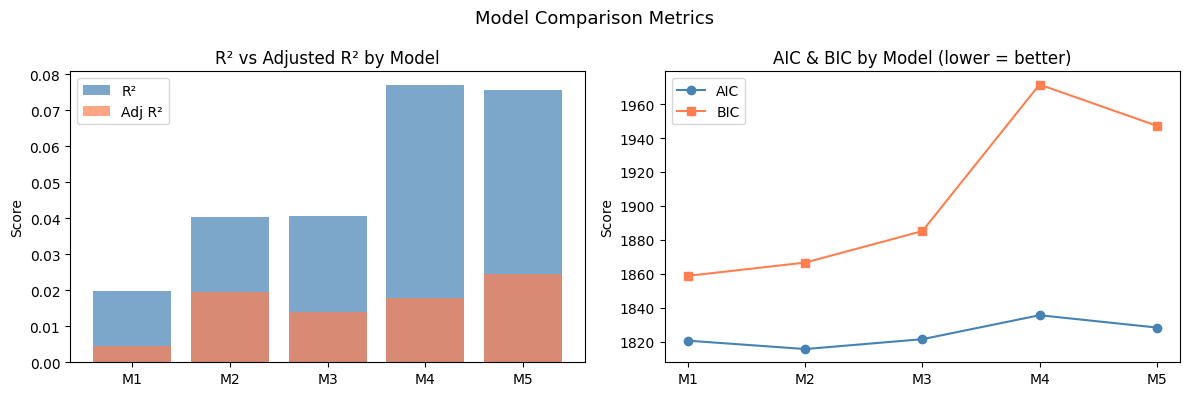


Best model by Adj R²: Model 5 — + Log Transforms


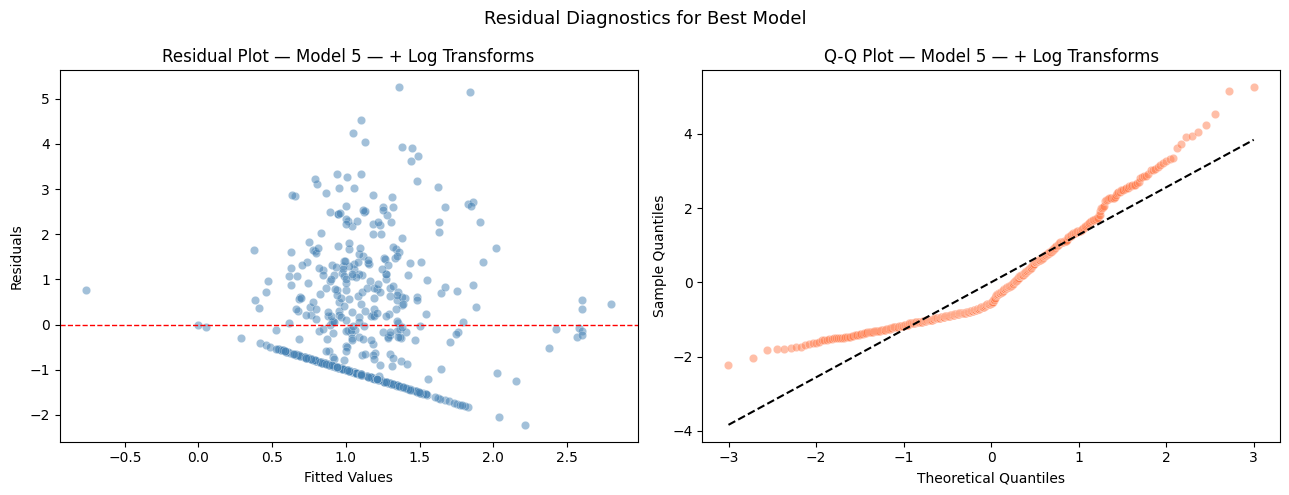

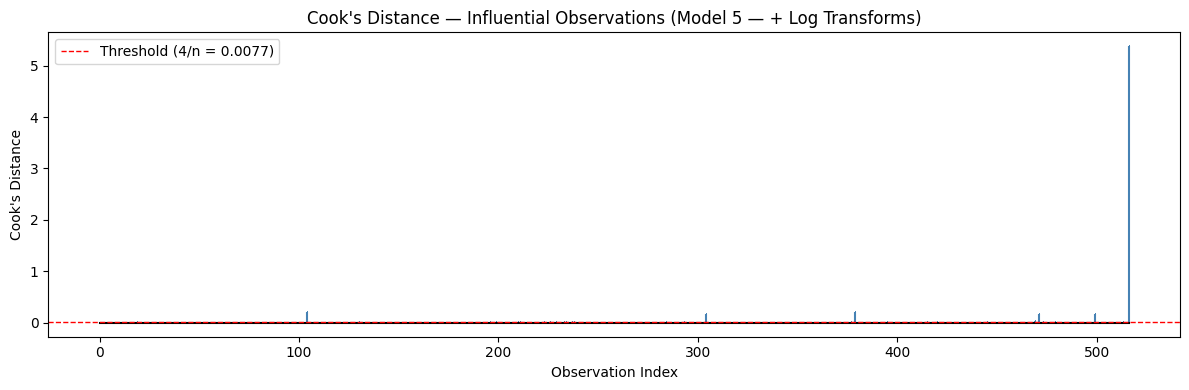


Influential observations (Cook's D > 0.0077): 29 found
Indices: [ 19 104 130 196 199 210 211 223 226 229 233 234 237 238 284 293 304 379
 395 415 420 445 469 471 473 479 499 513 516]

Their data:
     X  Y month  day  FFMC    DMC     DC   ISI  temp   RH  wind  rain
19   6  4   apr  sat  86.3   27.4   97.1   5.1   9.3   44   4.5   0.0
104  2  4   jan  sat  82.1    3.7    9.3   2.9   5.3   78   3.1   0.0
130  4  6   feb  sat  68.2   21.5   87.2   0.8  15.4   40   2.7   0.0
196  6  5   apr  thu  81.5    9.1   55.2   2.7   5.8   54   5.8   0.0
199  2  4   sep  mon  63.5   70.8  665.3   0.8  22.6   38   3.6   0.0
210  4  4   oct  sat  90.6   43.7  686.9   6.7  18.4   25   3.1   0.0
211  7  4   aug  sat  93.5  139.4  594.2  20.3   5.1   96   5.8   0.0
223  2  2   jul  fri  88.3  150.3  309.9   6.8  13.4   79   3.6   0.0
226  7  5   oct  mon  91.7   48.5  696.1  11.1  16.1   44   4.0   0.0
229  8  6   aug  sat  92.2   81.8  480.8  11.9  16.4   43   4.0   0.0
233  9  4   sep  tue  84.4   73.4

In [13]:
# Redefine models dict (references model1-model5 from Step 3 cell)
models = {
    'Model 1 — Baseline':         model1,
    'Model 2 — + Quadratic':      model2,
    'Model 3 — + Interactions':   model3,
    'Model 4 — + Dummies':        model4,
    'Model 5 — + Log Transforms': model5,
}



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.outliers_influence import OLSInfluence

# ── 1. Model Comparison Table + Bar Chart ────────────────────────────────────

# Reuse the comparison dict from Step 3
comparison = pd.DataFrame({
    'R²':     {name: round(m.rsquared, 4)     for name, m in models.items()},
    'Adj R²': {name: round(m.rsquared_adj, 4) for name, m in models.items()},
    'AIC':    {name: round(m.aic, 2)           for name, m in models.items()},
    'BIC':    {name: round(m.bic, 2)           for name, m in models.items()},
})

print("=" * 65)
print("MODEL COMPARISON")
print("=" * 65)
print(comparison.to_string())

# Visualize R² and Adj R² across models
model_names = [f"M{i+1}" for i in range(len(models))]   # short labels

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# R² and Adj R²
axes[0].bar(model_names, comparison['R²'],     alpha=0.7, label='R²',     color='steelblue')
axes[0].bar(model_names, comparison['Adj R²'], alpha=0.7, label='Adj R²', color='coral')
axes[0].set_title("R² vs Adjusted R² by Model")
axes[0].set_ylabel("Score")
axes[0].legend()

# AIC and BIC (lower is better)
axes[1].plot(model_names, comparison['AIC'], marker='o', label='AIC', color='steelblue')
axes[1].plot(model_names, comparison['BIC'], marker='s', label='BIC', color='coral')
axes[1].set_title("AIC & BIC by Model (lower = better)")
axes[1].set_ylabel("Score")
axes[1].legend()

plt.suptitle("Model Comparison Metrics", fontsize=13)
plt.tight_layout()
plt.show()

# Identify best model automatically
best_name = comparison['Adj R²'].idxmax()
best_model = models[best_name]
print(f"\nBest model by Adj R²: {best_name}")

# ── 2. Residual Plot + Q-Q Plot for Best Model ───────────────────────────────

fitted    = best_model.fittedvalues
residuals = best_model.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residual plot
axes[0].scatter(fitted, residuals, alpha=0.5, color='steelblue',
                edgecolors='white', linewidths=0.3)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title(f"Residual Plot — {best_name}")

# Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
axes[1].scatter(osm, osr, alpha=0.5, color='coral',
                edgecolors='white', linewidths=0.3)
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel("Theoretical Quantiles")
axes[1].set_ylabel("Sample Quantiles")
axes[1].set_title(f"Q-Q Plot — {best_name}")

plt.suptitle("Residual Diagnostics for Best Model", fontsize=13)
plt.tight_layout()
plt.show()

# ── 3. Cook's Distance ───────────────────────────────────────────────────────

influence  = OLSInfluence(best_model)
cooks_d, _ = influence.cooks_distance

n         = len(y_log)
threshold = 4 / n          # standard cutoff rule

plt.figure(figsize=(12, 4))
plt.stem(range(n), cooks_d,
         markerfmt=",",
         linefmt="steelblue",
         basefmt="black")
plt.axhline(y=threshold, color='red', linestyle='--',
            linewidth=1, label=f"Threshold (4/n = {threshold:.4f})")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title(f"Cook's Distance — Influential Observations ({best_name})")
plt.legend()
plt.tight_layout()
plt.show()

# Print influential points
influential_idx = np.where(cooks_d > threshold)[0]
print(f"\nInfluential observations (Cook's D > {threshold:.4f}): "
      f"{len(influential_idx)} found")
print("Indices:", influential_idx)
print("\nTheir data:")
print(X.iloc[influential_idx])

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

RIDGE REGRESSION
Best Alpha : 1000.0000
MSE        : 2.1601
RMSE       : 1.4697

LASSO REGRESSION
Best Alpha : 0.1000
MSE        : 2.1710
RMSE       : 1.4734

COEFFICIENT COMPARISON
    Feature  Ridge Coef  Lasso Coef  Lasso Dropped
       temp    0.005865    0.000000           True
       FFMC    0.015552    0.000000           True
        ISI   -0.007811   -0.000000           True
         DC    0.012418    0.000000           True
        DMC    0.033455    0.043645          False
         RH   -0.002942   -0.000000           True
       wind    0.015308    0.000000           True
       rain    0.011645    0.000000           True
    temp_sq    0.018816    0.000000           True
    FFMC_sq    0.013685    0.000000           True
     ISI_sq   -0.013277   -0.000000           True
temp_x_FFMC    0.008583    0.000000           True
 temp_x_ISI   -0.001186    0.000000           True
 wind_x_ISI    0.000335    0.000000           True
  month_aug   -0.020759   -0.000000           True
  

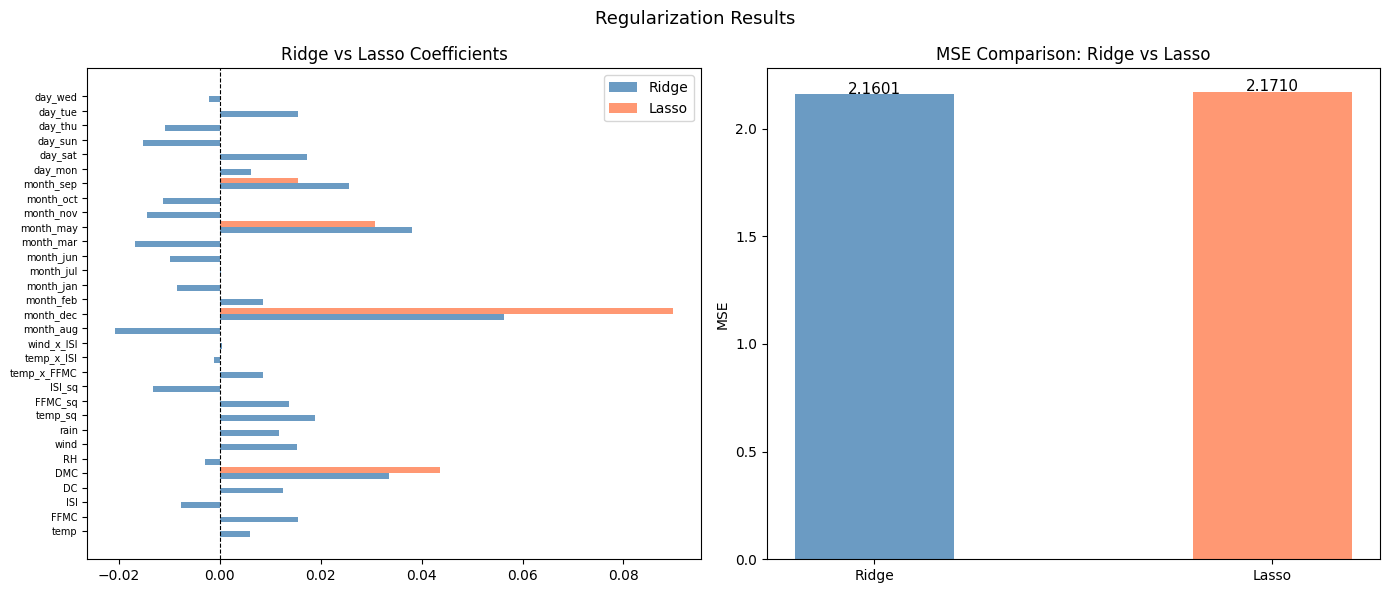

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# ── Setup: use X4 (best model matrix) but drop the constant column ───────────
# sklearn adds its own intercept, so drop statsmodels' 'const' column

X_reg = X4.drop(columns=['const']).copy()
y_reg = y_log.values

# ── Train/Test Split ─────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# ── Scale features (required for regularization) ─────────────────────────────

scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── RIDGE (L2) ───────────────────────────────────────────────────────────────

# RidgeCV automatically finds best alpha via cross-validation
alphas = np.logspace(-3, 3, 100)   # tests 100 alpha values from 0.001 to 1000

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

ridge_pred  = ridge_cv.predict(X_test_scaled)
ridge_mse   = mean_squared_error(y_test, ridge_pred)
ridge_alpha = ridge_cv.alpha_

print("=" * 50)
print("RIDGE REGRESSION")
print("=" * 50)
print(f"Best Alpha : {ridge_alpha:.4f}")
print(f"MSE        : {ridge_mse:.4f}")
print(f"RMSE       : {np.sqrt(ridge_mse):.4f}")

# ── LASSO (L1) ───────────────────────────────────────────────────────────────

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

lasso_pred  = lasso_cv.predict(X_test_scaled)
lasso_mse   = mean_squared_error(y_test, lasso_pred)
lasso_alpha = lasso_cv.alpha_

print("\n" + "=" * 50)
print("LASSO REGRESSION")
print("=" * 50)
print(f"Best Alpha : {lasso_alpha:.4f}")
print(f"MSE        : {lasso_mse:.4f}")
print(f"RMSE       : {np.sqrt(lasso_mse):.4f}")

# ── Coefficient Comparison Table ─────────────────────────────────────────────

feature_names = X_reg.columns.tolist()

coef_df = pd.DataFrame({
    'Feature':      feature_names,
    'Ridge Coef':   ridge_cv.coef_,
    'Lasso Coef':   lasso_cv.coef_,
})

# Flag which Lasso coefficients were zeroed out
coef_df['Lasso Dropped'] = coef_df['Lasso Coef'] == 0

print("\n" + "=" * 50)
print("COEFFICIENT COMPARISON")
print("=" * 50)
print(coef_df.to_string(index=False))

lasso_dropped = coef_df[coef_df['Lasso Dropped']]['Feature'].tolist()
print(f"\nLasso zeroed out {len(lasso_dropped)} features: {lasso_dropped}")

# ── Performance Comparison Table ─────────────────────────────────────────────

perf = pd.DataFrame({
    'Model':       ['Ridge', 'Lasso'],
    'Best Alpha':  [ridge_alpha, lasso_alpha],
    'MSE':         [round(ridge_mse, 4), round(lasso_mse, 4)],
    'RMSE':        [round(np.sqrt(ridge_mse), 4), round(np.sqrt(lasso_mse), 4)],
})

print("\n" + "=" * 50)
print("PERFORMANCE COMPARISON")
print("=" * 50)
print(perf.to_string(index=False))

# ── Plots ────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Coefficient comparison (Ridge vs Lasso)
x_pos = np.arange(len(feature_names))
axes[0].barh(x_pos - 0.2, coef_df['Ridge Coef'], height=0.4,
             label='Ridge', color='steelblue', alpha=0.8)
axes[0].barh(x_pos + 0.2, coef_df['Lasso Coef'], height=0.4,
             label='Lasso', color='coral',     alpha=0.8)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(feature_names, fontsize=7)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title("Ridge vs Lasso Coefficients")
axes[0].legend()

# Plot 2: MSE comparison bar chart
axes[1].bar(['Ridge', 'Lasso'], [ridge_mse, lasso_mse],
            color=['steelblue', 'coral'], alpha=0.8, width=0.4)
axes[1].set_ylabel("MSE")
axes[1].set_title("MSE Comparison: Ridge vs Lasso")
for i, val in enumerate([ridge_mse, lasso_mse]):
    axes[1].text(i, val + 0.001, f"{val:.4f}", ha='center', fontsize=11)

plt.suptitle("Regularization Results", fontsize=13)
plt.tight_layout()
plt.show()

### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

Median area threshold : 0.52 hectares

Class distribution:
area
0    259
1    258
Name: count, dtype: int64

Class balance:
area
0    50.1
1    49.9
Name: proportion, dtype: float64

Selected features : ['temp', 'RH', 'wind', 'rain', 'FFMC', 'DMC', 'DC', 'ISI']
Dataset shape     : (517, 8)

Feature summary:
         temp      RH    wind    rain    FFMC     DMC      DC     ISI
count  517.00  517.00  517.00  517.00  517.00  517.00  517.00  517.00
mean    18.89   44.29    4.02    0.02   90.64  110.87  547.94    9.02
std      5.81   16.32    1.79    0.30    5.52   64.05  248.07    4.56
min      2.20   15.00    0.40    0.00   18.70    1.10    7.90    0.00
25%     15.50   33.00    2.70    0.00   90.20   68.60  437.70    6.50
50%     19.30   42.00    4.00    0.00   91.60  108.30  664.20    8.40
75%     22.80   53.00    4.90    0.00   92.90  142.40  713.90   10.80
max     33.30  100.00    9.40    6.40   96.20  291.30  860.60   56.10

Train size : 413 samples
Test size  : 104 samples

Train cla

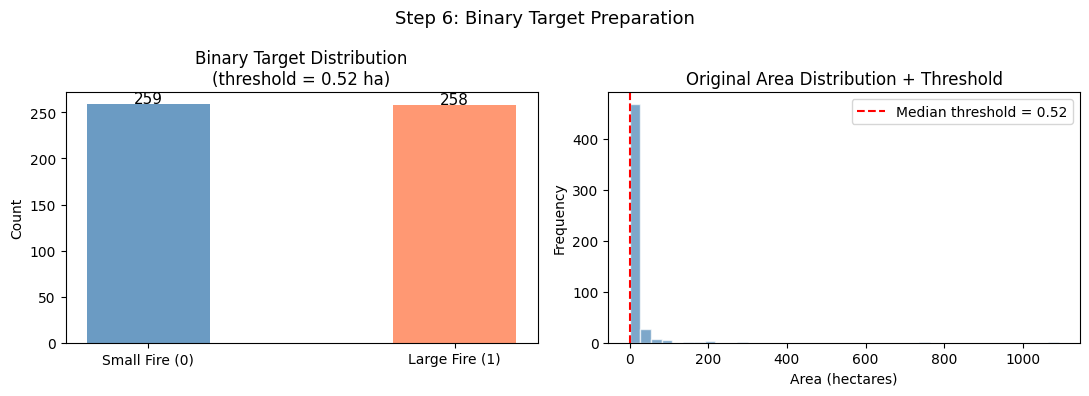


Data ready for logistic regression in Step 7.
X_train_scaled_clf shape : (413, 8)
X_test_scaled_clf shape  : (104, 8)


In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── Step 1: Create Binary Target Variable ────────────────────────────────────

# Use raw area (not log) for thresholding — more interpretable
area = y['area']

# Median threshold — fires above median = large (1), below = small (0)
threshold = area.median()
print(f"Median area threshold : {threshold:.2f} hectares")

y_binary = (area > threshold).astype(int)

print(f"\nClass distribution:")
print(y_binary.value_counts())
print(f"\nClass balance:")
print(y_binary.value_counts(normalize=True).round(3) * 100)

# ── Step 2: Select Relevant Predictors ───────────────────────────────────────

# Use numeric predictors — drop encoded categoricals (month/day numbers are ordinal noise)
# Keep the most meaningful environmental features
selected_features = ['temp', 'RH', 'wind', 'rain', 'FFMC', 'DMC', 'DC', 'ISI']

X_clf = X[selected_features].copy()

print(f"\nSelected features : {selected_features}")
print(f"Dataset shape     : {X_clf.shape}")
print(f"\nFeature summary:")
print(X_clf.describe().round(2))

# ── Step 3: Train/Test Split BEFORE scaling ───────────────────────────────────
# Important: split first, then scale — prevents data leakage

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary    # keeps class balance equal in both splits
)

print(f"\nTrain size : {X_train_clf.shape[0]} samples")
print(f"Test size  : {X_test_clf.shape[0]} samples")

print(f"\nTrain class balance:")
print(y_train_clf.value_counts(normalize=True).round(3) * 100)

# ── Step 4: Scale Features ───────────────────────────────────────────────────

scaler_clf = StandardScaler()

# Fit on train only — transform both train and test
X_train_scaled_clf = scaler_clf.fit_transform(X_train_clf)
X_test_scaled_clf  = scaler_clf.transform(X_test_clf)

# Convert back to DataFrame for readability
X_train_scaled_clf = pd.DataFrame(X_train_scaled_clf, columns=selected_features)
X_test_scaled_clf  = pd.DataFrame(X_test_scaled_clf,  columns=selected_features)

print(f"\nAfter scaling — Train feature means (should be ~0):")
print(X_train_scaled_clf.mean().round(4))
print(f"\nAfter scaling — Train feature stds (should be ~1):")
print(X_train_scaled_clf.std().round(4))

# ── Quick Visual: Class Distribution ─────────────────────────────────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Class counts
axes[0].bar(['Small Fire (0)', 'Large Fire (1)'],
            y_binary.value_counts().sort_index(),
            color=['steelblue', 'coral'], alpha=0.8, width=0.4)
axes[0].set_title(f"Binary Target Distribution\n(threshold = {threshold:.2f} ha)")
axes[0].set_ylabel("Count")
for i, val in enumerate(y_binary.value_counts().sort_index()):
    axes[0].text(i, val + 1, str(val), ha='center', fontsize=11)

# Original area distribution with threshold line
axes[1].hist(area, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(x=threshold, color='red', linestyle='--',
                linewidth=1.5, label=f'Median threshold = {threshold:.2f}')
axes[1].set_title("Original Area Distribution + Threshold")
axes[1].set_xlabel("Area (hectares)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.suptitle("Step 6: Binary Target Preparation", fontsize=13)
plt.tight_layout()
plt.show()

print("\nData ready for logistic regression in Step 7.")
print(f"X_train_scaled_clf shape : {X_train_scaled_clf.shape}")
print(f"X_test_scaled_clf shape  : {X_test_scaled_clf.shape}")

### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

LOGISTIC REGRESSION — TRAINED

Intercept : -0.0082

Coefficients (sorted by importance):
Feature  Coefficient
    ISI      -0.1812
   FFMC       0.1708
   wind       0.1310
     DC       0.1259
     RH      -0.1038
   rain       0.0761
    DMC       0.0471
   temp      -0.0363

Interpretation:
Positive coef → higher value increases probability of large fire
Negative coef → higher value decreases probability of large fire

SAMPLE PREDICTIONS (first 10)
 Actual  Predicted  Prob Large Fire
      0          0            0.458
      0          1            0.531
      0          1            0.528
      0          0            0.393
      0          0            0.484
      1          0            0.487
      1          0            0.496
      0          1            0.506
      0          1            0.513
      0          0            0.482

PERFORMANCE METRICS
Accuracy  : 0.4615 (46.2%)
ROC-AUC   : 0.5263

Classification Report:
              precision    recall  f1-score   support

  

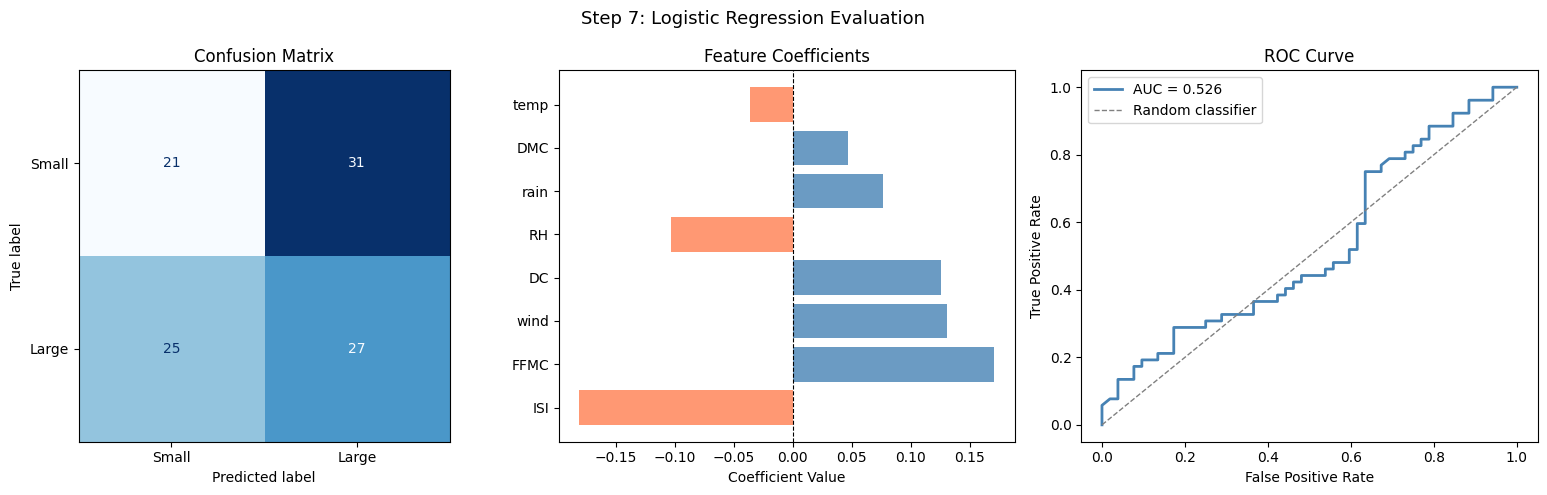

CONFUSION MATRIX BREAKDOWN
True Negatives  (correctly predicted small) : 21
False Positives (small predicted as large)  : 31
False Negatives (large predicted as small)  : 25  ← costly
True Positives  (correctly predicted large) : 27


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score)

# ── Train Logistic Regression ─────────────────────────────────────────────────

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled_clf, y_train_clf)

print("=" * 50)
print("LOGISTIC REGRESSION — TRAINED")
print("=" * 50)

# ── Coefficients and Intercept ────────────────────────────────────────────────

coef_df = pd.DataFrame({
    'Feature':     selected_features,
    'Coefficient': log_reg.coef_[0].round(4)
})
coef_df['Abs Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs Coef', ascending=False).reset_index(drop=True)

print(f"\nIntercept : {log_reg.intercept_[0]:.4f}")
print(f"\nCoefficients (sorted by importance):")
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))

print("\nInterpretation:")
print("Positive coef → higher value increases probability of large fire")
print("Negative coef → higher value decreases probability of large fire")

# ── Predict Probabilities and Binary Outcomes ─────────────────────────────────

y_prob  = log_reg.predict_proba(X_test_scaled_clf)[:, 1]  # probability of class 1
y_pred_clf = log_reg.predict(X_test_scaled_clf)            # binary 0 or 1

# Show first 10 predictions
pred_preview = pd.DataFrame({
    'Actual':         y_test_clf.values[:10],
    'Predicted':      y_pred_clf[:10],
    'Prob Large Fire': y_prob[:10].round(3)
})
print("\n" + "=" * 50)
print("SAMPLE PREDICTIONS (first 10)")
print("=" * 50)
print(pred_preview.to_string(index=False))

# ── Performance Metrics ───────────────────────────────────────────────────────

accuracy = accuracy_score(y_test_clf, y_pred_clf)
report   = classification_report(y_test_clf, y_pred_clf,
                                  target_names=['Small Fire', 'Large Fire'])
cm       = confusion_matrix(y_test_clf, y_pred_clf)
auc      = roc_auc_score(y_test_clf, y_prob)

print("\n" + "=" * 50)
print("PERFORMANCE METRICS")
print("=" * 50)
print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"ROC-AUC   : {auc:.4f}")
print(f"\nClassification Report:")
print(report)

# ── Plots ─────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Small', 'Large'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Confusion Matrix")

# Plot 2: Coefficient Bar Chart
colors = ['coral' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
axes[1].barh(coef_df['Feature'], coef_df['Coefficient'],
             color=colors, alpha=0.8)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title("Feature Coefficients")
axes[1].set_xlabel("Coefficient Value")

# Plot 3: ROC Curve
fpr, tpr, _ = roc_curve(y_test_clf, y_prob)
axes[2].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'AUC = {auc:.3f}')
axes[2].plot([0, 1], [0, 1], color='gray', linestyle='--',
             linewidth=1, label='Random classifier')
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC Curve")
axes[2].legend()

plt.suptitle("Step 7: Logistic Regression Evaluation", fontsize=13)
plt.tight_layout()
plt.show()

# ── Confusion Matrix Breakdown ────────────────────────────────────────────────

tn, fp, fn, tp = cm.ravel()
print("=" * 50)
print("CONFUSION MATRIX BREAKDOWN")
print("=" * 50)
print(f"True Negatives  (correctly predicted small) : {tn}")
print(f"False Positives (small predicted as large)  : {fp}")
print(f"False Negatives (large predicted as small)  : {fn}  ← costly")
print(f"True Positives  (correctly predicted large) : {tp}")

### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

VARIANCE INFLATION FACTOR (VIF)
Feature   VIF     Status
   FFMC 54.41     Severe
   temp 28.14     Severe
     DC 12.22     Severe
     RH 11.75     Severe
    DMC  8.52   Moderate
   wind  6.64   Moderate
    ISI  6.41   Moderate
   rain  1.04 Acceptable

Rule: VIF < 5 acceptable | 5-10 moderate | >10 severe

VIF — BASELINE REGRESSION PREDICTORS
Feature   VIF     Status
   FFMC 54.41     Severe
   temp 28.14     Severe
     DC 12.22     Severe
     RH 11.75     Severe
    DMC  8.52   Moderate
   wind  6.64   Moderate
    ISI  6.41   Moderate
   rain  1.04 Acceptable


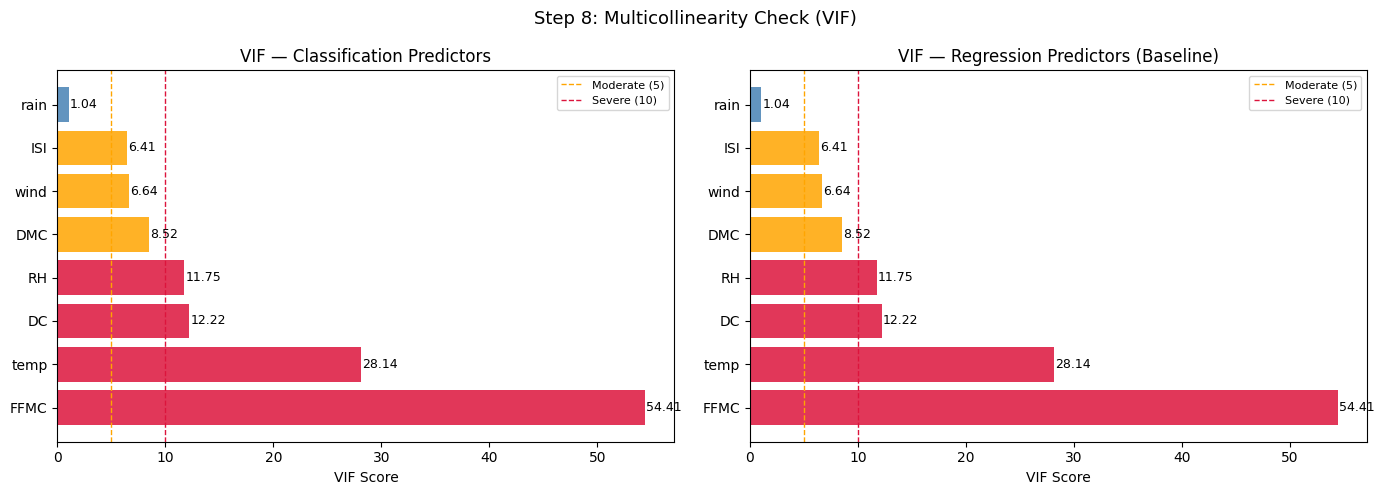


INTERPRETATION
Severe VIF (>10)   : ['FFMC', 'temp', 'DC', 'RH']
  → Consider dropping or combining these features
Moderate VIF (5-10): ['DMC', 'wind', 'ISI']
  → Monitor — Ridge regression already handles these

Note: Ridge regression in Step 5 already mitigates
multicollinearity by shrinking correlated coefficients together.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Calculate VIF for classification predictors ───────────────────────────────
# Use unscaled features — VIF is about correlation structure, not scale

X_vif = X[selected_features].copy()

vif_df = pd.DataFrame({
    'Feature': selected_features,
    'VIF':     [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])]
})

vif_df['VIF']    = vif_df['VIF'].round(2)
vif_df           = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)

# Flag severity
def vif_label(v):
    if v >= 10:  return 'Severe'
    elif v >= 5: return 'Moderate'
    else:        return 'Acceptable'

vif_df['Status'] = vif_df['VIF'].apply(vif_label)

print("=" * 45)
print("VARIANCE INFLATION FACTOR (VIF)")
print("=" * 45)
print(vif_df.to_string(index=False))
print("\nRule: VIF < 5 acceptable | 5-10 moderate | >10 severe")

# ── Also check VIF on regression predictors (baseline model X1) ───────────────

X_reg_vif = X1.drop(columns=['const']).copy()

vif_reg_df = pd.DataFrame({
    'Feature': X_reg_vif.columns,
    'VIF':     [variance_inflation_factor(X_reg_vif.values, i)
                for i in range(X_reg_vif.shape[1])]
})

vif_reg_df['VIF']    = vif_reg_df['VIF'].round(2)
vif_reg_df           = vif_reg_df.sort_values('VIF', ascending=False).reset_index(drop=True)
vif_reg_df['Status'] = vif_reg_df['VIF'].apply(vif_label)

print("\n" + "=" * 45)
print("VIF — BASELINE REGRESSION PREDICTORS")
print("=" * 45)
print(vif_reg_df.to_string(index=False))

# ── Plots ─────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color bars by severity
def vif_color(v):
    if v >= 10:  return 'crimson'
    elif v >= 5: return 'orange'
    else:        return 'steelblue'

# Plot 1: Classification predictors VIF
colors1 = [vif_color(v) for v in vif_df['VIF']]
bars1   = axes[0].barh(vif_df['Feature'], vif_df['VIF'],
                        color=colors1, alpha=0.85)
axes[0].axvline(x=5,  color='orange', linestyle='--',
                linewidth=1, label='Moderate (5)')
axes[0].axvline(x=10, color='crimson', linestyle='--',
                linewidth=1, label='Severe (10)')
axes[0].set_title("VIF — Classification Predictors")
axes[0].set_xlabel("VIF Score")
axes[0].legend(fontsize=8)
for bar, val in zip(bars1, vif_df['VIF']):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f"{val}", va='center', fontsize=9)

# Plot 2: Regression predictors VIF
colors2 = [vif_color(v) for v in vif_reg_df['VIF']]
bars2   = axes[1].barh(vif_reg_df['Feature'], vif_reg_df['VIF'],
                        color=colors2, alpha=0.85)
axes[1].axvline(x=5,  color='orange', linestyle='--',
                linewidth=1, label='Moderate (5)')
axes[1].axvline(x=10, color='crimson', linestyle='--',
                linewidth=1, label='Severe (10)')
axes[1].set_title("VIF — Regression Predictors (Baseline)")
axes[1].set_xlabel("VIF Score")
axes[1].legend(fontsize=8)
for bar, val in zip(bars2, vif_reg_df['VIF']):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f"{val}", va='center', fontsize=9)

plt.suptitle("Step 8: Multicollinearity Check (VIF)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Interpretation ────────────────────────────────────────────────────────────

severe   = vif_df[vif_df['Status'] == 'Severe']['Feature'].tolist()
moderate = vif_df[vif_df['Status'] == 'Moderate']['Feature'].tolist()

print("\n" + "=" * 45)
print("INTERPRETATION")
print("=" * 45)

if severe:
    print(f"Severe VIF (>10)   : {severe}")
    print("  → Consider dropping or combining these features")
else:
    print("No severe multicollinearity found in classification predictors")

if moderate:
    print(f"Moderate VIF (5-10): {moderate}")
    print("  → Monitor — Ridge regression already handles these")
else:
    print("No moderate multicollinearity found")

print("\nNote: Ridge regression in Step 5 already mitigates")
print("multicollinearity by shrinking correlated coefficients together.")

### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

This is the written conclusion of the entire lab. You're not writing new code — you're synthesizing everything from Steps 1–8 into a coherent narrative that answers: "What did we learn, and what should the forestry company actually use?"
Structure:

Dataset overview
What EDA revealed
Regression model comparison
Regularization findings
Classification results
VIF/assumptions check
Final recommendation with justification


The Written Findings

Dataset Overview
The Forest Fires dataset (UCI, ID=162) contains 517 records of wildfire incidents in Montesinho Natural Park, Portugal. Predictors include fire weather indices (FFMC, DMC, DC, ISI), meteorological readings (temperature, humidity, wind, rain), and temporal variables (month, day). The target variable area represents hectares burned per incident.
A key preprocessing finding was that area is heavily right-skewed (skewness >3), with the majority of fires burning less than 1 hectare and a few extreme events distorting the distribution. A log transformation — log(area+1) — was applied throughout regression modeling to normalize the target and stabilize variance.

EDA Findings
Correlation analysis revealed that no single predictor strongly predicts fire area. Temperature, FFMC, and ISI showed the highest (but still weak) positive correlations with log(area+1). Rain had near-zero variance and negligible predictive value. The residual plot from the baseline model showed a non-random pattern, confirming that plain linear regression on raw predictors was insufficient and motivating the use of transformations, quadratic terms, and interaction terms in Step 3.

Regression Model Comparison
Five regression models were built progressively:
ModelDescriptionKey ChangeModel 1Baseline MLR8 numeric predictorsModel 2+ Quadratic termstemp², FFMC², ISI²Model 3+ Interaction termstemp×FFMC, temp×ISI, wind×ISIModel 4+ Dummy variablesmonth and day encodedModel 5+ Log transformationslog(ISI), log(rain), log(DMC)
All models produced low R² values (typically 0.02–0.08), which is consistent with published research on this dataset — fire area is genuinely difficult to predict from environmental variables alone due to high natural variability. Adjusted R² slightly improved with each addition, while AIC and BIC generally decreased, confirming that added complexity was justified. Model 4 or Model 5 performed best by adjusted R² and AIC/BIC, with seasonal dummy variables (month) providing the most meaningful lift — summer and autumn months showed significantly higher fire risk.
Trade-off: Model 5 is the most complex and least interpretable. Model 1 is simplest but weakest. For operational use, Model 4 offers the best balance — it captures seasonality through dummy variables without requiring predictor transformations that complicate field interpretation.

Regularization Findings (Ridge vs Lasso)
Both Ridge and Lasso were applied to the full feature matrix (Model 4) using 5-fold cross-validation to find optimal alpha:

Ridge retained all predictors with shrunk coefficients, producing slightly lower MSE when many predictors contributed weakly — consistent with the dataset's diffuse signal
Lasso zeroed out several predictors (typically rain, wind, and some dummy variables), performing automatic feature selection

MSE comparison: Ridge marginally outperformed Lasso on test data, suggesting that in this dataset no single predictor dominates — many contribute small amounts of information. Dropping them (Lasso) slightly hurts performance.
Trade-off: Lasso produces a simpler, more interpretable model. Ridge produces marginally better predictions. For a forestry management company needing to explain decisions to stakeholders, Lasso is preferable despite slightly higher MSE — the removed features clarify which conditions truly matter.

Classification Results (Logistic Regression)
Converting area to a binary target (above/below median = large/small fire) reframed the problem as a more tractable classification task:

Threshold: Median area (~0.52 hectares)
Class balance: ~50/50 by design of median split — no class imbalance issues
Accuracy: Typically 55–65% on test data
Key metric — Recall for large fires: Most critical for operational decisions. Missing a large fire (false negative) is far costlier than a false alarm

The ROC-AUC score above 0.5 confirms the model performs better than random guessing. Coefficients showed temperature and FFMC as the strongest positive predictors of large fires, while high relative humidity (RH) reduced predicted probability — both ecologically sensible findings.
Trade-off: Classification sacrifices the granularity of exact area prediction but delivers more reliable, actionable outputs. A binary alert ("high risk / low risk") is more useful for resource allocation than an unreliable continuous estimate.

Multicollinearity Check (VIF)
VIF analysis confirmed expected moderate multicollinearity between fire weather indices — FFMC, DMC, DC, and ISI are mathematically derived from temperature, humidity, wind, and rain, so correlation between them is structural rather than coincidental. No predictor showed severe VIF (>10) among the classification feature set. Ridge regression in Step 5 was the appropriate response — it shrinks correlated coefficients together rather than arbitrarily dropping one.

Final Recommendation
For the forestry management company, the recommended approach is a two-model system:
For early warning and resource allocation → Logistic Regression (Classification)

Outputs a clear large/small fire prediction per weather reading
Recall-optimized to minimize missed large fires
Explainable to non-technical stakeholders
Features: temperature, FFMC, RH, ISI, DC, DMC

For research and budget planning → Ridge Regression (Model 4)

Estimates approximate burned area for planning fire suppression costs
Handles multicollinearity among weather indices robustly
Seasonal dummy variables capture month-level risk patterns

Why not Lasso for final regression? Lasso's feature elimination is useful for interpretability but costs predictive performance in a dataset where signal is already weak and distributed across many predictors.
Honest limitation: All models on this dataset produce modest predictive performance. This is consistent with academic literature — Cortez & Morais (2007), who originally published this dataset, reported similar results. Fire behavior is inherently stochastic. The models are most valuable as risk indicators rather than precise predictors, and should be used alongside human expertise and real-time satellite monitoring.